Button(description='Generate and Display Graph', style=ButtonStyle())

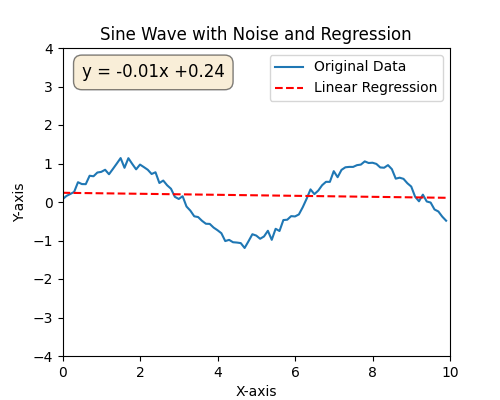

In [1]:
import ipywidgets as widgets
from IPython.display import display
#import tkinter as tk # navnekonvensjon
#from tkinter import ttk

import numpy as np # navnekonvensjon
import pandas as pd # navnekonvensjon
import matplotlib.pyplot as plt # navnekonvensjon
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import scipy.stats as stats

def draw_plot(b): # snake_case
    # np.random brukes her for generering av et tall
    # hvis vi ikke bruker seed blir grafen forkjellig hver gang knappen klikkes
    #np.random.seed(42) # seed(42) gir samme startpunkt for random hver gang programmet starter
    #https://numpy.org/doc/stable/reference/random/generated/numpy.random.seed.html#numpy-random-seed

    # en dictionary = {key1: value1, key2: value2, ...} 
    #https://docs.python.org/3/tutorial/datastructures.html#dictionaries

    # data er en dictionary med key 'X' og 'Y'
    # value for X er en rekke/array som genereres med np.arange 
    #https://numpy.org/doc/2.3/reference/generated/numpy.arange.html

    # np.arange tar argument: start, stop, step - 0, 10, 0.1 slik at det blir 100 tall i rekken/array
    # np.sin utfører sinusfunksjonen på tallet en gir til den 
    #https://numpy.org/doc/2.3/reference/generated/numpy.sin.html

    # np.sin(np.arange ... sender en rekke med tall til sinus funksjonen og det kommer ut en rekke med sinusverdier
    # len(np.arange(0, 10, 0.1) gir tallet som er lengden på rekken/array, som er 100
    #https://docs.python.org/3/library/functions.html#len

    # np.random.normal(0, 0.1, 100) gir en rekke med 100 normalfordelte tall rundt 0 med standardavvik 0.1
    #https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html#numpy-random-normal
    #https://www.khanacademy.org/math/ap-statistics/density-curves-normal-distribution-ap/stats-normal-distributions/v/ck12-org-normal-distribution-problems-empirical-rule
    # Normalfordelt betyr
    # med den empiriske regelen kan vi si at 99.7% av tallene er mellom -0.3 og 0.3 når standardavviket er 0.1

    # når en bruker + mellom en numpy array/rekke og en annen numpy array/rekke så vil tallene i array/rekkene på hver sin plass 
    # legges sammen og gi en ny array/rekke
    # hvis rekkene har samme form og størelse
    #https://numpy.org/devdocs/user/quickstart.html#basic-operations
 
    # sinusverdiene er 100 tall mellom -1 og 1
    # value for Y er derfor en array/rekke med 100 tall der 99.7% av tallene er mellom -1.3 og 1.3
    # 
    data = {'X': np.arange(0, 10, 0.1),
            'Y': np.sin(np.arange(0, 10, 0.1)) + np.random.normal(0, 0.1, len(np.arange(0, 10, 0.1)))}

    # pd.DataFrame(...) er en Constructor som lager en pandas dataframe av vår dicionary med numpy rekker
    #https://pandas.pydata.org/docs/reference/frame.html
    #https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html
    #
    df = pd.DataFrame(data)

    # stats.linregress(df['X'], df['Y']) er en scipy funksjon som beregner linær regresjon for vår pandas dataframe
    # og vi får en regresjonslinje vi kan tegne
    #https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html#scipy.stats.linregress
    slope, intercept, r_value, p_value, std_err = stats.linregress(df['X'], df['Y'])
    regression_line = slope * df['X'] + intercept
    formula_text = f'y = {slope:.2f}x {intercept:+.2f}'

    # Vi tegner en figur av pandas dataframe og scipy regresjonslinje med matplotlib
    #https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
    # plt.subplots
    # fig, ax = plt.subplots(figsize=(5, 4))
    ax.clear()
    ax.plot(df['X'], df['Y'], label='Original Data')
    ax.plot(df['X'], regression_line, color='red', linestyle='--', label='Linear Regression')
    ax.set_title('Sine Wave with Noise and Regression')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.legend()
    ax.set_xlim(0, 10)
    ax.set_ylim(-4, 4)
    ax.text(0.05, 0.95, formula_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
    # plt.tight_layout()

    #https://matplotlib.org/stable/api/backend_tk_api.html#matplotlib.backends.backend_tkagg.FigureCanvasTkAgg
    # Med Tkinter får vi en boks vi kan gjøre interaktiv med knapper og inndata hvis vi vil
    # matplotlib figuren legges inn i boksen 
    # canvas = FigureCanvasTkAgg(fig, master=root)
    # canvas_widget = canvas.get_tk_widget()
    # canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=1)
    fig.canvas.draw()#canvas.draw()

# lager tkinter vinduet
#root = tk.Tk()
#root.title("Datavisualisering med tkinter, pandas, numpy, scipy og matplotlib.")

%matplotlib widget

# heller en at figuren tegnes i funksjonen oppdateres den i funksjonen
# figuren tegnes her og legges til widget
fig, ax = plt.subplots(figsize=(5,4))
ax.set_title("Click the button")

#canvas = FigureCanvasTkAgg(fig, master=root)
#canvas_widget = canvas.get_tk_widget()
#canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=1)

# Knapp for å tegne graf
plot_button = widgets.Button(description="Generate and Display Graph") #ttk.Button(root, text="Generate and Display Graph", command=draw_plot)
plot_button.on_click(draw_plot)#pack(pady=10)
display(plot_button)
# kjører funksjonen 1 gang først slik at figuren ikke er tom
draw_plot(None)

# Kjører tkinter
#root.mainloop()

